### Import

In [1]:
import os
import gc
import time
import pickle 
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm
import matplotlib.ticker as ticker
from matplotlib import pyplot as plt 

from typing import Dict
from typing import Callable
from plot_metric.functions import BinaryClassification

import statsmodels.api as sm
from scipy.stats import spearmanr

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import auc
from sklearn.metrics import f1_score 
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from aequitas.bias import Bias
from aequitas.group import Group
from aequitas.plotting import Plot
from aequitas.fairness import Fairness

pd.set_option('display.max_columns', 500)

### General parameters

In [2]:
race_path  = "Extraction/MIMICIII/Data/csvExtract/"
path_data  = "../Data/EHR/"
path_cohort= "../Data/Cohorts/"

### Read Cohorts Splits

In [3]:
with open(path_cohort + "short_icustays", "rb") as fp:   
    short_icustays = pickle.load(fp)
    
with open(path_cohort + "train_icustays", "rb") as fp:   
    train_icustays = pickle.load(fp)
    
with open(path_cohort + "valid_icustays", "rb") as fp:   
    valid_icustays = pickle.load(fp)
    
with open(path_cohort + "test_icustays", "rb") as fp:   
    test_icustays = pickle.load(fp)
    
with open(path_cohort + "icustays_ehr_text", "rb") as fp:   
    icustays_ehr_text = pickle.load(fp)
    
with open(path_cohort + "icustays_ehr_only", "rb") as fp:   
    icustays_ehr_only = pickle.load(fp)
    
with open(path_cohort + "note_ids_24h", "rb") as fp:   
    note_ids_24h = pickle.load(fp)

### Reading Data

In [4]:
static_col = ['ICUSTAY_ID', 'Bins', 'AGE', 'GENDER', 'ETHNICITY',  'SOFA', 'SAPSII', 'OASIS', 'ICU_EXPIRE_FLAG']

df_ehr = pd.read_csv(path_data + '0h_to_24h_data.csv', low_memory=False, index_col=False, usecols=static_col)
df_ehr = df_ehr.drop_duplicates()
df_ehr.head(2)

In [5]:
print(df_ehr.ICUSTAY_ID.nunique())
print(df_ehr.shape)

59653
(1333367, 9)


### Remove Short Stays

In [6]:
df_ehr = df_ehr[~df_ehr.ICUSTAY_ID.isin(short_icustays)]

In [7]:
print(df_ehr.ICUSTAY_ID.nunique())
print(df_ehr.shape)

54632
(1244312, 9)


### Take first 24 hour LoS

In [9]:
max_rows = df_ehr.groupby('ICUSTAY_ID').count()
observation_window = max_rows.Bins.max()
print(observation_window)

24


In [10]:
def take_observation_window(df, observation_window):
    df = df.groupby('ICUSTAY_ID').head(observation_window).reset_index(drop=True)
    return df

df_ehr = take_observation_window(df_ehr, observation_window)

### Spliting Train - Validation - Test

In [12]:
label = 'ICU_EXPIRE_FLAG'

In [13]:
train_df = df_ehr[df_ehr.ICUSTAY_ID.isin(train_icustays)]
valid_df = df_ehr[df_ehr.ICUSTAY_ID.isin(valid_icustays)]
test_df  = df_ehr[df_ehr.ICUSTAY_ID.isin(test_icustays)]

train_df.sort_values(by=['ICUSTAY_ID', 'Bins'], inplace=True)
valid_df.sort_values(by=['ICUSTAY_ID', 'Bins'], inplace=True)
test_df.sort_values( by=['ICUSTAY_ID', 'Bins'], inplace=True)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

### Variables Selection

In [15]:
risk_scores = ['SOFA', 'SAPSII', 'OASIS']

static_col = ['AGE', 'GENDER', 'ETHNICITY']

### Imputation

In [16]:
def Imputation(train_df, valid_df, test_df, risk_scores):
    
    train_df_temp = train_df.copy()
        
    for i in sorted(risk_scores):
        
        valid_df[i].fillna(method='ffill', inplace=True)
        test_df[i].fillna(method ='ffill', inplace=True)
        train_df[i].fillna(method='ffill', inplace=True)
        
        valid_df[i].fillna(method='bfill', inplace=True)
        test_df[i].fillna(method ='bfill', inplace=True)
        train_df[i].fillna(method='bfill', inplace=True)
        
        valid_df[i].fillna((train_df_temp[i].mean()), inplace=True)
        test_df[ i].fillna((train_df_temp[i].mean()), inplace=True)
        train_df[i].fillna((train_df_temp[i].mean()), inplace=True)
        
    train_df = train_df.round(2)
    valid_df = valid_df.round(2)
    test_df  = test_df.round(2)
            
    return train_df, valid_df, test_df

In [17]:
train_df, valid_df, test_df = Imputation(train_df, valid_df, test_df, risk_scores)

### Plots

In [18]:
def ROC_curve(true_label, prediction_prob):
    
    AUC = roc_auc_score(true_label, prediction_prob)
    fpr, tpr, roc_thresholds = roc_curve(true_label, prediction_prob)

    fig, ax = plt.subplots(figsize=(4, 3), dpi=120)
    plt.plot(fpr, tpr, color='darkorange', lw=1.2, label='Model (AUC = {:.2f})'.format(AUC))
    plt.plot([0, 1], [0, 1], color='navy', lw=1.2, linestyle='--', label='Random (AUC = 0.50)')
    plt.xlim([-0.01, 1.00])
    plt.ylim([ 0.00, 1.02])
    plt.xlabel('False Positive Rate', fontsize=8)
    plt.ylabel('True Positive Rate', fontsize=8)
    plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [19]:
def PRC_REC_curve(true_label, prediction_prob):
    
    AP = average_precision_score(true_label, prediction_prob)
    precision, recall, pr_thresholds = precision_recall_curve(true_label, prediction_prob)
    no_skill = len(true_label[true_label == 1]) / len(true_label) 

    fig, ax = plt.subplots(figsize=(4, 3), dpi=120)
    plt.plot(recall, precision, color='darkorange', lw=1.2, label='Model (AP = {:.2f})'.format(AP))
    plt.plot([0, 1], [no_skill, no_skill], color='navy', lw=1.2, linestyle='--', label='No Skill (AP = {:.2f})'.format(no_skill))
    plt.xlim([-0.01, 1.00])
    plt.ylim([ 0.00, 1.02])
    plt.xlabel('Recall', fontsize=8)
    plt.ylabel('Precision', fontsize=8)
    plt.title('Precision-Recall Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [20]:
def Calibration_curve(true_label, prediction_prob):
    
    fig, ax = plt.subplots(figsize=(5, 2.5), dpi=120)
    
    frac_of_pos, mean_pred_value = calibration_curve(true_label, prediction_prob, n_bins=10)

    plt.plot([0, 1], [0, 1], "--", label="Perfectly Calibrated", color='navy', lw=1.3)
    plt.plot(mean_pred_value, frac_of_pos, "*-", label='Model Calibration', lw=1.2, color='darkorange')

    plt.ylabel("Fraction of Positives", fontsize=8)
    plt.xlabel("Mean Predicted Value", fontsize=8)
    plt.ylim([-0.05, 1.05])
    plt.xlim([-0.05, 1.05])
    plt.title('Calibration Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [21]:
def Confusion_Matrix(true_label, predicted_label, classes, cmap=plt.cm.OrRd):
    
    cm = confusion_matrix(true_label, predicted_label, labels=[1, 0])

    plt.figure(figsize = (5, 5))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title('Confusion Matrix', size = 14)
    plt.colorbar(aspect=4)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=40, size = 14)
    plt.yticks(tick_marks, classes, size = 14)

    fmt = 'd'
    thresh = cm.max() / 2.
    
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), fontsize = 14,
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
        
    plt.tight_layout()
    plt.ylabel('True Label', size = 13)
    plt.xlabel('Predicted Label', size = 13)
    plt.show()

### Performance

In [22]:
def Prediction_Labels_Thresholding(true_label, prediction_prob, decision_recall):
    
    precision, recall, pr_thresholds = precision_recall_curve(true_label, prediction_prob, pos_label=1)
    
    index = np.argwhere(recall >= decision_recall)[-1][0]
    decision_threshold = pr_thresholds[index]
    predicted_label = (np.array(prediction_prob) > decision_threshold).astype(int)
    
    print("Decision Threshold is: ", np.round(decision_threshold, 2))
    
    return predicted_label, decision_threshold

In [23]:
def Performance_Metrics(true_label, predicted_label, prediction_prob):
    
    TN, FP, FN, TP = confusion_matrix(true_label, predicted_label).ravel()

    ACC = (TP+TN)/(TP+FP+FN+TN)
    PRC = TP/(TP+FP)
    REC = TP/(TP+FN)
    F1M = (2*PRC*REC)/(PRC+REC)
    PPV = TP/(TP+FP)
    NPV = TN/(TN+FN)
    SEN = TP/(TP+FN)
    SPE = TN/(TN+FP) 
    FPR = FP/(FP+TN)
    FNR = FN/(TP+FN)
    FDR = FP/(TP+FP)

    AUC = roc_auc_score(true_label, prediction_prob)
    AP  = average_precision_score(true_label, prediction_prob)
    MCC = matthews_corrcoef(true_label, predicted_label)
    
    print("ACC = " , np.round(ACC, 2)), print("PRC = " , np.round(PRC, 2))
    print("REC = " , np.round(REC, 2)), print("F1M = " , np.round(F1M, 2))
    print("PPV = " , np.round(PPV, 2)), print("NPV = " , np.round(NPV, 2))
    print("SEN = " , np.round(SEN, 2)), print("SPE = " , np.round(SPE, 2))
    print("FPR = " , np.round(FPR, 2)), print("FNR = " , np.round(FNR, 2))
    print("FDR = " , np.round(FDR, 2)), print("AUC = " , np.round(AUC, 2))
    print("AP  = " , np.round(AP,  2)), print("MCC = " , np.round(MCC, 2))

In [24]:
def performance_metric(true_labels, pred_probs):
    
    precision, recall, pr_thresholds = precision_recall_curve(true_labels, pred_probs)
    decision_recall = 0.8
    index = np.argwhere(recall >= decision_recall)[-1][0]
    decision_threshold = pr_thresholds[index]
    predicted_label = (np.array(pred_probs) > decision_threshold).astype(int)

    acc = accuracy_score(true_labels, predicted_label)
    auc = roc_auc_score(true_labels, pred_probs)
    f1  = f1_score(true_labels, predicted_label)
    precision = precision_score(true_labels, predicted_label)
    recall = recall_score(true_labels, predicted_label)
    pr_auc = average_precision_score(true_labels, pred_probs)
    ppv = precision  
    npv = precision_score(true_labels, predicted_label, pos_label=0) 
    mcc = matthews_corrcoef(true_labels, predicted_label)
    
    metrics = {'ACC': np.round(acc, 2),
               'PRC': np.round(precision, 2),
               'REC': np.round(recall, 2),
               'F1M': np.round(f1, 2),
               'PPV': np.round(ppv, 2),
               'NPV': np.round(npv, 2),
               'AUC': np.round(auc, 2),
               'AP': np.round(pr_auc, 2),
               'MCC': np.round(mcc, 2),
               'THRSH':np.round(decision_threshold, 2)
              }
    
    return metrics

### Select Target Tool

In [72]:
# target_tool = 'OASIS'
# target_tool = 'SAPSII'
target_tool = 'SOFA'

### Data Preparation

In [73]:
train_demographics = train_df[['ICUSTAY_ID', 'AGE', 'GENDER', 'ETHNICITY', 'ICU_EXPIRE_FLAG']].copy()
valid_demographics = valid_df[['ICUSTAY_ID', 'AGE', 'GENDER', 'ETHNICITY', 'ICU_EXPIRE_FLAG']].copy()
test_demographics  = test_df[[ 'ICUSTAY_ID', 'AGE', 'GENDER', 'ETHNICITY', 'ICU_EXPIRE_FLAG']].copy()

train_demographics = train_demographics.drop_duplicates()
valid_demographics = valid_demographics.drop_duplicates()
test_demographics  = test_demographics.drop_duplicates()

In [74]:
train_df_data = train_df[['ICUSTAY_ID', 'Bins', target_tool]].copy()
valid_df_data = valid_df[['ICUSTAY_ID', 'Bins', target_tool]].copy()
test_df_data  = test_df[[ 'ICUSTAY_ID', 'Bins', target_tool]].copy()

pivoted_train_df = train_df_data.pivot(index='ICUSTAY_ID', columns='Bins', values=target_tool)
pivoted_valid_df = valid_df_data.pivot(index='ICUSTAY_ID', columns='Bins', values=target_tool)
pivoted_test_df  = test_df_data.pivot( index='ICUSTAY_ID', columns='Bins', values=target_tool)

columns = [f"hour_{col}" for col in pivoted_train_df.columns]

pivoted_train_df.columns = [f"hour_{col}" for col in pivoted_train_df.columns]
pivoted_valid_df.columns = [f"hour_{col}" for col in pivoted_valid_df.columns]
pivoted_test_df.columns  = [f"hour_{col}" for col in pivoted_test_df.columns]

pivoted_train_df = pivoted_train_df.reset_index()
pivoted_valid_df = pivoted_valid_df.reset_index()
pivoted_test_df  = pivoted_test_df.reset_index()

In [75]:
train_df_final = train_demographics.merge(pivoted_train_df, on='ICUSTAY_ID', how='left')
valid_df_final = valid_demographics.merge(pivoted_valid_df, on='ICUSTAY_ID', how='left')
test_df_final  = test_demographics.merge(pivoted_test_df  , on='ICUSTAY_ID', how='left')

### Results based on Worst Clinical Risk Score

In [82]:
highest_risk_df = test_df_data.groupby('ICUSTAY_ID').max()[[target_tool]].reset_index()

highest_risk_df = test_demographics.merge(highest_risk_df, on='ICUSTAY_ID', how='left')

highest_risk_df['probability'] = (highest_risk_df[target_tool] - df_ehr[target_tool].min()) / (df_ehr[target_tool].max() - df_ehr[target_tool].min())

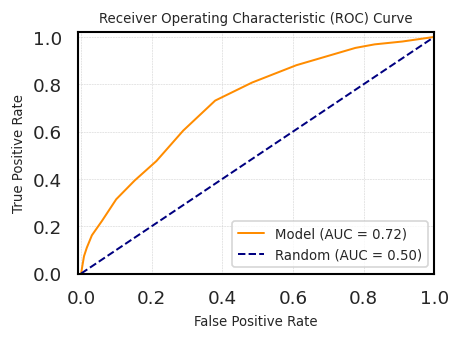

In [83]:
ROC_curve(highest_risk_df.ICU_EXPIRE_FLAG, highest_risk_df.probability)

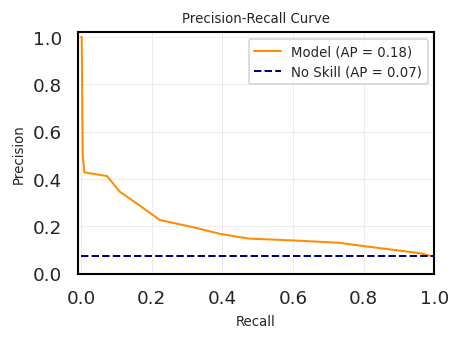

In [84]:
PRC_REC_curve(highest_risk_df.ICU_EXPIRE_FLAG, highest_risk_df.probability)

### Set Decision Threshold

In [86]:
decision_recall = 0.8

In [87]:
predicted_label_tool, decision_threshold_tool = Prediction_Labels_Thresholding(highest_risk_df.ICU_EXPIRE_FLAG, 
                                                                               highest_risk_df.probability, 
                                                                               decision_recall)

highest_risk_df['predicted_label'] = predicted_label_tool

Decision Threshold is:  0.24


### Confusion Matrix

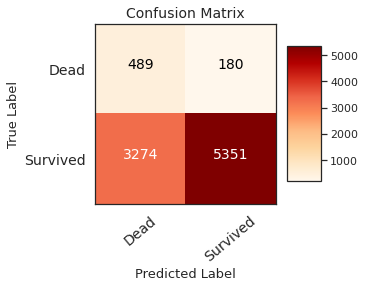

In [88]:
Confusion_Matrix(highest_risk_df.ICU_EXPIRE_FLAG, highest_risk_df.predicted_label, classes = ['Dead', 'Survived'])

### Performance Metrics

In [89]:
Performance_Metrics(highest_risk_df.ICU_EXPIRE_FLAG, highest_risk_df.predicted_label, highest_risk_df.probability)

ACC =  0.63
PRC =  0.13
REC =  0.73
F1M =  0.22
PPV =  0.13
NPV =  0.97
SEN =  0.73
SPE =  0.62
FPR =  0.38
FNR =  0.27
FDR =  0.87
AUC =  0.72
AP  =  0.18
MCC =  0.18


### Distribution of Prediction Probabilities

In [90]:
highest_risk_df['ICU_FLAG'] = 'Survived'
highest_risk_df.loc[highest_risk_df.ICU_EXPIRE_FLAG == 1, 'ICU_FLAG'] = 'Dead'

In [91]:
df_prediction_lstm_alive = highest_risk_df[highest_risk_df['ICU_FLAG'] == 'Survived']
df_prediction_lstm_dead  = highest_risk_df[highest_risk_df['ICU_FLAG'] == 'Dead']

### Alive Patients

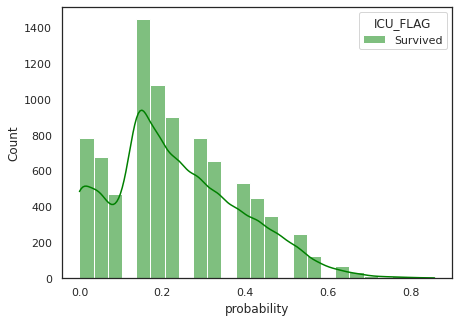

In [92]:
plt.figure(figsize=(7, 5))
sns.set(font_scale= 1)
sns.set_style(style='white')
sns.histplot(data=df_prediction_lstm_alive, x='probability', kde=True, stat='count', bins=25, fill=True,
             legend=True, hue='ICU_FLAG', palette=['green'])
plt.show()

### Dead Patients

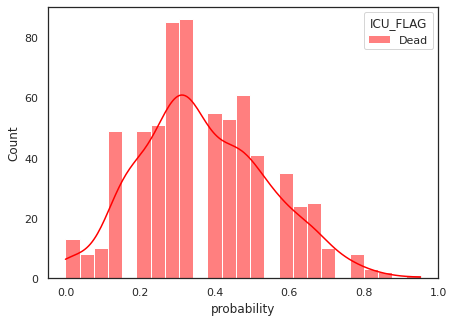

In [93]:
plt.figure(figsize=(7, 5))
sns.set(font_scale= 1)
sns.set_style(style='white')
sns.histplot(data=df_prediction_lstm_dead, x='probability', kde=True, stat='count', bins=25, fill=True,
             legend=True, hue='ICU_FLAG', palette=['red'])
plt.show()

### Save Results

In [95]:
# highest_risk_df.to_csv("./Results/OASIS_Result.csv" , index=False)
# highest_risk_df.to_csv("./Results/SAPSII_Result.csv", index=False)
# highest_risk_df.to_csv("./Results/SOFA_Result.csv"  , index=False)